# Extension to a multi-dimensional and time-dependent Problem

In [1]:
import os
# Surpress unnecessary output from tensorflow package
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
# Change the working dorectory, for easier imports and running
os.chdir(os.path.dirname(os.path.abspath('../pyproject.toml')))

# Import necessary functions/ packages
from Utils.plot import int_3D_plot, plot_animated, simp_plot, plot_err_vs_epoch, plot_twoD_error, mult_3D_plot
from PINNLearning.data import gen_data, set_boundaries, time_sim, gen_rand_2D_data, set_2D_boundaries, twoD_sim
from PINNLearning.training import learning_rate_schedule, time_loss, twoD_loss, train
from PINNLearning.models import create_model
import matplotlib.pyplot as plt
from tensorflow import keras
import tensorflow as tf
import numpy as np

As before, we are setting some initial settings primarily for plotting.

In [2]:
# Plot settings
plt.close('all')
plt.rcParams['font.size'] = 10

# Dimensions of the simulation space
lower_bound = 0.0
upper_bound = 1.0

## Introduction to time-dependence

We continue the exploration of the heat equation written below, but this time we will consider it as time-dependent.

$$\dfrac{\partial u(x, t)}{\partial t} = \alpha \cdot \Delta u(x, t)$$

To accommodate this change, the initial simplifications need to be adjusted as follows:
- The diffusion factor is set to a constant value: $\alpha = 0.1$
- The function remains one-dimensional, so we still have: $\Delta u(x, t) = \frac{\partial^2 u(x, t)}{\partial^2x}$


In this context, the diffusion factor $\alpha$ is reduced to extend the "time" it takes for the heat to spread throughout the system. This adjustment aids the PINN in converging, as neural networks often struggle with complex, erratic functions. This issue was also observed in the previous section of the notebook `1D & time independent` problems. Furthermore this leads to nicer looking results.

The problem remains normalized over the range $[0,1]$, and this normalization extends to the time domain.
The Dirichlet boundary conditions are specified across the entire time range similar to before:

$u(0) = 1$ and $u(1) = 0$

Additionally, we need to introduce an initial condition for $u(x,0)$, which is defined as:

$u(x,0) = 0.5 \cdot cos(2 \cdot \pi \cdot x) + 0.5$ 

**It is not strictly required for the initial solution to satisfy the boundary conditions outlined above. However, if the initial solution does not meet these conditions, the solutions may exhibit some errors in relation to the problem's definition.**

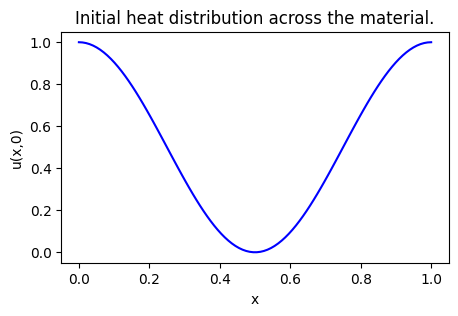

In [3]:
# Create the data for the simulation and set the initial solution

# Discretize the x dimension
x_train = gen_data(lower_bound, upper_bound, 100)

# Set the boundary conditions
x_bc, y_bc = set_boundaries([[0.0], [1.0]], [[1.0], [0.0]])

# Create a function to generate the initial solution for t=0
def init_sol(array):
    # set the initial function to be compatible 
    # with both, np and tf
    if isinstance(array, tf.Tensor):
        init = 0.5 * tf.cos(2 * tf.experimental.numpy.pi * array) + 0.5
    else:
        init = 0.5 * np.cos(2 * np.pi * array) + 0.5
    return init

# Set an examplery initial solution 
init_vals = init_sol(x_train)

# View the initial solution
plt = simp_plot([x_train, init_vals, 'b'],
                'Initial heat distribution across the material.',
                ylabel='u(x,0)'
                )
plt.show()

Due to the complexity of finding an analytical solution, a simulated approach is employed again, which is based on the finite differences method. 
In this simulation, time is discretized into small intervals, and the solution is computed at each time step. This necessitates an important **stability condition**, which establishes a relationship between the step sizes (denoted as $\Delta$) in the $x$ and $t$ domains.
To achieve this, the second derivative of the PDE is replaced with the second-order central difference, as seen previously. In contrast to before, the first-order forward difference is incorporated for the time variable. In this context, the discretized steps in the spatial domain are denoted by $i$, while the steps in the time domain are represented by $n$. By isolating the value for the next time step, we arrive at the following equation:


$$u_i^{n+1} \approx \underbrace{\alpha \cdot \dfrac{\Delta t}{\Delta x^2}}_{\hat{=} r} \cdot \left[ u_{i+1}^n - 2 \cdot u_i^n + u_{i+1}^n \right] + u_i^n$$

The aformentioned condition is known as the _Courant-Friedrichs-Lewy (CFL)_ condition, which states:

$$r = \alpha \cdot \dfrac{\Delta t}{\Delta x^2} \overset{!}{\leq} \dfrac{1}{2}$$

With the fixed discretization of the spatial domain and the specified value for $\alpha$, the CFL condition serves as the foundation for calculating the discretization of the time domain. However, since all domains are normalized, this will not impact the visual outcome of the simulation.

In [4]:
# Simulate the PDE
final_res, hist, times = time_sim(x_train, y_bc, init_sol, 5)


Converged at time t=3.11478s in 30528 steps.


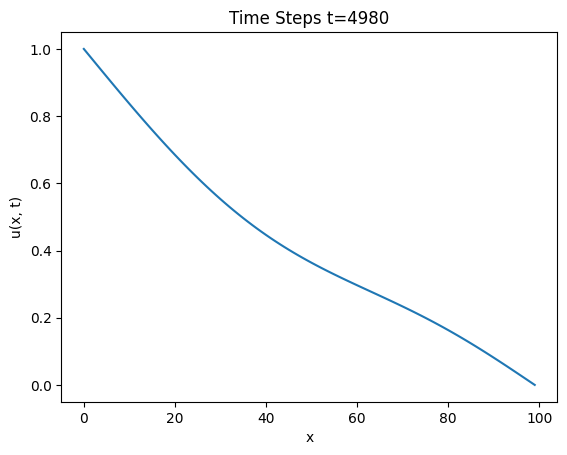

In [5]:
# Plot an animation of the initial development over time
# FYI: This plot is limited in the displayed time frame
# and does not show full convergence!
plot_animated(hist[:5000:20], pause=0.0001, iterator=20)


In [6]:
# Create a 3D plot of the simulation

# Limit the number of displayed time steps, for easier plotting
hist = hist[::20]

m = len(hist)      # number of time steps
n = len(hist[0])   # number of x samples

# Set up the axis
x = np.linspace(lower_bound, upper_bound, n)  # spatial dimension
z = np.linspace(lower_bound, upper_bound, m)  # temporal dimension - normalized to be in [0, 1]
X, Z = np.meshgrid(x, z)
Y = np.array(hist)  # results

plt = int_3D_plot(X, Z, Y, "Plot of the simulated spatio-temporal solution", ylabel='t', zlabel='z(x, t)')
plt.show()

In this scenario, the following setup of the PINN differs significantly from that of the simulation.
This problem must be treated here as a **two-dimensional problem** in both space and time. Consequently, the training and validation data must be sampled from the $x-t~plane$, and the boundary conditions themselves must be represented as _arrays of constant samples_ across the time domain.

With this added complexity, it is evident that the model must also increase in complexity. To accommodate this, the neural network now includes _more_ hidden layers. Additionally, the training budget needs to be _expanded_, the training duration will be _longer_, and the learning rate must initially be _increased_ before being gradually reduced according to the schedule. Other modifications to the framework focus primarily on adjusting the residual to be minimized and incorporating the initial solution as an additional loss term.

In this implementation, it is unlikely that the model will converge to a final solution, instead, it exhausts the training budget.
Training performance could be enhanced by further increasing the budget, the number of data points and **batching** the training data. **Batching** can be activated by providing the ```train()``` function with a specified **batch size**.
Against typicall practices, for PINNs much larger batch sizes (a typicall size would otherwise be 32) are recommended ([Sankaran S. et al., 2022](https://www.semanticscholar.org/paper/On-the-impact-of-larger-batch-size-in-the-training-Sankaran-Wang/6a89167f1764acf26e8f34871d71e65ab7a47263)). Here the author got the best results without the learning rate scheduler and a batch size of 256.

Batching is a technique used to _improve the efficiency and performance_ of training algorithms. Instead of processing the entire dataset at once, the data is divided into smaller subsets called batches or mini-batches. Each batch contains a certain power of two of randomly selected data points from the original dataset.
During training, the model is updated individually for each batch. In addition to the obvious benefits of reducing memory requirements, this approach leads to a "noisy" gradient, which can enhance exploration, and results in a higher update frequency. This may lead to faster convergence.

However, a downside is that as the number of batches increases, the gradients of the model need to be computed more frequently. This differentiation is the most time-intensive step of the learning process and can become a limiting factor in the use of this technique if sufficient parallelization is not possible. Furthermore the convergence itself is sensitive to the batch size. Although it's effect varies from proplem to problem. The same applies for the learning rate.


See for more information the article of [Bipin Krishnan P., 2019](https://medium.com/analytics-vidhya/when-and-why-are-batches-used-in-machine-learning-acda4eb00763).

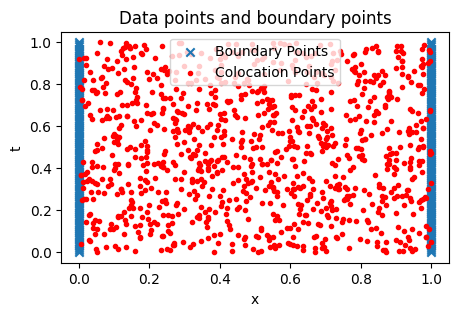

In [7]:
# Create the training and validation data set for the PINN

# Sample 1000 (x, t) pairs for training
xt_train = gen_rand_2D_data(lower_bound, upper_bound, 1000)

# Generate 900 (x, t) pairs for verification
x_samps = gen_data(lower_bound, upper_bound, 30)
t_samps = gen_data(lower_bound, upper_bound, 30)
grid = tf.meshgrid(x_samps, t_samps)
grid = tf.stack(grid, axis=-1)
xt_test = tf.reshape(grid, [-1, 2])


# Extend the given boudary values to fit the 2D approach
# FYI: As the boundary conditions are set as u(<x_bound>, t), they must be provided
# as a vector of values, sampled throught the time domain. For the t_sample points,
# we are using here the x_train vector just for simplicity.
xt_bc, yt_bc = set_2D_boundaries(x_bc, y_bc, x_train)


# Plot the data points
data = [
    [xt_bc[:, 0], xt_bc[:, 1], ('marker', 'x'), 'scatter', ('label', 'Boundary Points')],
    [xt_train[:, 0], xt_train[:, 1], ('marker', '.'), ('c', 'r'), 'scatter', ('label', 'Colocation Points')]
    ]
plt = simp_plot(data, "Data points and boundary points", ylabel="t")
plt.show()


In [8]:
# Train/Test a model for a simple time dependent case

# FYI: The only modifications to make this algoritm capable of 2D are in the loss function.
# However, also the training budget (limit epochs) and the learning rate schedule were
# increased to improve performance.

# Create a model
model = create_model(5, 50)

# Create a learning rate schedule
lr_schedule = learning_rate_schedule(1e-2, 6000, 0.1)

# Closure function for to convert the time_loss for the train function
def loss(model, y_true, x_bc, y_bc):
    return time_loss(model, y_true, x_bc, y_bc, init_sol)


# Train the model if it is not already trained
try:
    # To force retraining of the model uncomment follwing line
    ## raise Exception

    model = keras.models.load_model('./data/time_dep.keras')
except Exception as e:
    error_time = train(model, xt_train, xt_bc, yt_bc, loss, lr_schedule, threshold=1e-8, limit=4500)
    model.save('./data/time_dep.keras')

    # Create a graph showing the loss vs the epochs
    x, y = zip(*error_time)
    data = list([x, y, 'g-', 'Model Loss'])
    plt = plot_err_vs_epoch(data, 'Development of the Loss over the Epochs', xlabel='Epochs', ylabel='Loss')
    plt.show()


# Calculate the predictions for the verification data
y_pred = model(xt_test).numpy()

# Create a 3D plot of the preditction of the PINN
X, Z = np.meshgrid(x_samps, t_samps)
Y = y_pred.reshape(30, 30)  # results

plt = int_3D_plot(X, Z, Y, 'Plot of the spatio-temporal PINN solution', zlabel='u(x)', ylabel='Time t')
plt.show()

The comparison between the simulation results and those obtained from the PINN reveals visually comparable solutions. However, the PINN results exhibit a more ragged appearance in certain areas, which can be attributed to the significantly fewer data points used for plotting this graph.

At the initial time point, it is evident that the right peak of the initial cosine function is **not accurately represented**. Instead of reaching a peak, it declines to a lower value. This discrepancy arises from a **mismatch** between the boundary conditions and the initial condition at this position. Such a mismatch creates a _discontinuity_, which complicates the learning process for the PINN, as previously demonstrated in the section about **spectral bias** in the notebook `1D & time independent`. To address this issue effectively, it may **NOT** be sufficient to just pose matching conditions or to ensure that they are not active at the same moment, as will be mentioned in the following sections.

First, a more detailed analysis is provided in the accompanying heatmap, which illustrates the absolute differences between the simulation values and the corresponding predictions from the PINN. Notably, a relatively _large discrepancy_ is observed, particularly in the lower "middle" section of the heatmap. This difference arises from the _slower_ convergence of the initial solution towards the linear region within the PINN framework.
The observed divergence is likely due to the PINN not fully converging to the final solution, which results in a misalignment of the actual scaling of the time domains. This is evidenced by the remaining curvature at time $t=1$. The incomplete convergence is further exacerbated by the larger residual error during training and the fact, that the maximum number of epochs probably serves as the limiting factor in this context, rather than the minimum change threshold.

These issue are a **common challenge** faced by PINNs. When time-dependency is involved, PINNs often struggle with **proper convergence**, resulting in lower accuracy. This difficulty arises from treating the time domain as a _"normal"_ spatial domain, which can lead to significant _error propagation_ and _non-physical solutions_. Specifically, the inherent _directionality_ and _causality_ of time are not adequately respected, as the model learns from random points throughout the entire problem domain, failing to account for the fact that future states should depend solely on past states.
This also indicates that boundary conditions even established from later points in time, will **continue to influence the resolution of the initial condition**, as they are effectively learned concurrently.
The solution to this challenge is currently a hot topic of research. Several modifications to the standard PINN framework have been proposed. Notable among these are **domain decomposition** and **causal/sequential training**. For further details, you can refer to this [Roy P. and Castonguay S., 2024](https://arxiv.org/abs/2403.03223v2).

The first approach, **domain decomposition**, involves _dividing the computational domain_ of the problem (in time, space, or both) into smaller, sometimes overlapping **subdomains**. Traditionally, separate neural networks are then trained on each subdomain, and their _solutions are combined_ to create the overall solution. This method generally enhances the accuracy of the PINNs.
These modifications are most commonly directly implemented in frameworks such as [FBPINN](https://link.springer.com/article/10.1007/s10444-023-10065-9), [cPINN](https://www.sciencedirect.com/science/article/abs/pii/S0045782520302127) and [XPINN](https://github.com/AmeyaJagtap/XPINNs). However, this approach introduces an additional condition: **continuity at the transition points** between subdomains. This continuity is enforced through the incorporation of extra loss terms. When using a single model these conditons are automatically satisfied, however this reduces the benefit of this method to a more granular control over the learning parameters (e.g. sampling density or loss weighting) across the domain. For more detailed information abou this general topic, you can refer to this [Heinlein A. et al., 2024](https://arxiv.org/abs/2401.07888v2).

The second approach focuses on techniques that explicitly honor the inherent _causality_ present in time-dependent physical problems.
This is primarily achieved through methods such as [causality-guided adaptive sampling](https://arxiv.org/abs/2409.01536), where training points are sampled from temporal windows that move along the time domain during training. Another method is [loss weighting/reweighting](https://www.sciencedirect.com/science/article/abs/pii/S0045782524000690), which involves weighting the residuals for each point. In this approach, the residuals at later times are initially given less weight, gaining importance only after the earlier times have been sufficiently learned.

It is becoming increasingly common to combine both approaches. This integration facilitates the alignment of subdomains and enhances computational scalability. For example, see [Sundar R. et al., 2025](https://arxiv.org/abs/2503.15679v1) and [Luo D. et al., 2025](https://www.mdpi.com/2227-7390/13/9/1515).

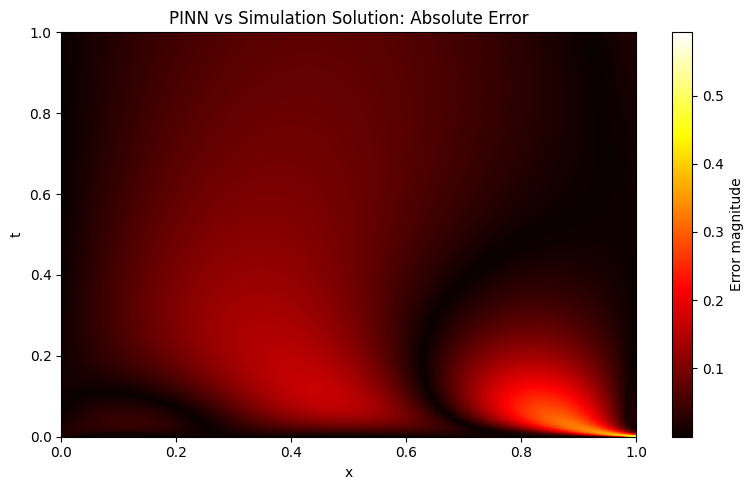

In [9]:
# Overview of the error between the PINN and simulation solutions

plt = plot_twoD_error('PINN vs Simulation Solution: Absolute Error', model, hist, x, z, ylabel='t')
plt.show()

# Two Dimensional Problems

Most physical problems involve multiple dimensions rather than just one. In this context, we are examining the **2D heat equation**. This is enough as extending this to additional dimensions is relatively straightforward from this point.
The 2D equation we are solving is:

$$u(x, z) = \alpha \cdot \left(\dfrac{\partial^2 u(x, z)}{\partial x^2} + \dfrac{\partial^2 u(x, z)}{\partial z^2}\right)$$

In this equation, the second spatial dimension is represented by $z$, while $y$ is still used to denote the corresponding values of the points across the domain. The diffusion coefficient $\alpha$ is set to $0.1$, the same value used in the previous problem.

Since we are now dealing with _two_ spatial dimensions, we need to establish _four_ boundary conditions. The existing **Dirichlet** boundary conditions are supplemented with **Neumann** boundary conditions for the z-domain. This results in the following conditions:

Dirichlet:
- $u(0,z) = 1$
- $u(1,z) = 0$

Neumann:
- $\dfrac{\partial u(x, z)}{\partial z} \Bigg|_{z = 0} = 0.5$
- $\dfrac{\partial u(x, z)}{\partial z} \Bigg|_{z = 1} = 0.5$


These changes require significant adjustments to the PINN loss function. First, the derivative with respect to the second spatial dimension needs to be included. It’s important to determine how to separate the two variables (e.g. whether to do so before or after differentiation) and how to implement the calculations. This decision can greatly _impact the accuracy_ of the resulting residual computation. The second addition involves incorporating the Neumann boundaries as a third loss term.
For both the iterative simulation scheme and the PINN, a question arises regarding _which boundary conditions take precedence_ at the corner points in the domain. After conducting experimental variations, it appears that the order does not significantly impact the results for this problem. Therefore, for simplicity, the implementations have been set with the Dirichlet boundaries taking precedence.

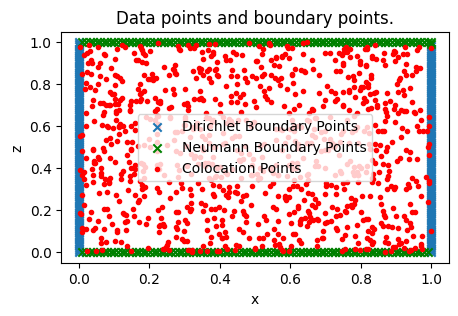

In [10]:
# Create the training and validation data set for the PINN
# and the boundary values for the simulation

# Sample 1000 (x, z) pairs for training
xz_train = gen_rand_2D_data(lower_bound, upper_bound, 1000)

# Generate 900 (x, z) pairs for verification
x_samps = gen_data(lower_bound, upper_bound, 30)
z_samps = gen_data(lower_bound, upper_bound, 30)
grid = tf.meshgrid(x_samps, z_samps)
grid = tf.stack(grid, axis=-1)
xz_test = tf.reshape(grid, [-1, 2])


# Create the Dirichlet/Neumann Boundaries for the x and z domain
x_bc, y_bc = set_boundaries([[0.0], [1.0], [0.0], [1.0]],  # x/z values
                            [[1.0], [0.0], [0.5], [0.5]])  # corresponding 'y' values
                            #  Dirichlet  |   Neumann

# Extend the given boudary values to fit the 2D approach
xz_bc, yz_bc = set_2D_boundaries(x_bc, y_bc, x_train)

# Plot the data points
data = [
    [xz_bc[:len(xz_bc)//2, 0], xz_bc[:len(xz_bc)//2, 1], ('marker', 'x'), 'scatter', ('label', 'Dirichlet Boundary Points')],
    [xz_bc[len(xz_bc)//2:, 0], xz_bc[len(xz_bc)//2:, 1], ('marker', 'x'), 'scatter', ('c', 'g'), ('label', 'Neumann Boundary Points')],
    [xz_train[:, 0], xz_train[:, 1], ('marker', '.'), ('c', 'r'), 'scatter', ('label', 'Colocation Points')]
    ]
plt = simp_plot(data, "Data points and boundary points.", ylabel="z")
plt.show()

In the simulation, both derivatives are substituted with their second-order central difference equivalents. The x-domain is discretized into steps of size $\Delta x$, indexed by $i$. Similarly, the second spatial domain (z-domain) is divided into steps of size $\Delta z$, indexed by $j$. Rearranging this equation to isolate $u_{i,j}(x, z)$ results in the following update function:

$$
u_{i,j} \approx \alpha \cdot \left[\dfrac{u_{i-1,j} \cdot u_{i+1,j}}{\Delta x^2} + \dfrac{u_{i,j-1} + u_{i,j+1}}{\Delta z^2} \right] \cdot \left(1 + \dfrac{2 \cdot \alpha}{\Delta x^2} + \dfrac{2 \cdot \alpha}{\Delta z^2} \right)^{-1}
$$

In this context, the denominator on the right can be precomputed to enhance performance.
Given the presence of Neumann boundary conditions, it is essential to rewrite these conditions in terms of finite differences to facilitate their enforcement during the iterative simulation process. For this purpose, the first-order forward difference is applied for the lower bound, while the first-order backward difference is utilized for the upper bound. The equations are ultimately rearranged to allow for the calculation of the values at the boundary points.

Boundary at $z = 0$:

$\dfrac{\partial u(x, z)}{\partial z} \approx \dfrac{u_{i,1} - u_{i,0}}{\Delta z} = 0.5 \hspace{1.85cm}\longrightarrow\hspace{1cm} u_{i,0} \approx u_{i,1} - 0.5 \cdot \Delta z$


Boundary at $z = 1$:

$\dfrac{\partial u(x, z)}{\partial z} \approx \dfrac{u_{i,j_{max}-1} - u_{i,j_{max}-2}}{\Delta z} = 0.5 \hspace{0.5cm}\longrightarrow\hspace{1cm} u_{i,j_{max}-1} \approx u_{i,j_{max}-2} - 0.5 \cdot \Delta z$

In these equations, $j_{max}$ denotes the index of the point on the upper bound. The Neumann boundary conditions are applied in each iteration of the algorithm, ensuring that these conditions are consistently enforced throughout the simulation.

In [11]:
# Simulation results for the 2D equation
res = twoD_sim(x_train, y_bc)

# Plot the simulated solution
m = len(res)      # number of z samples
n = len(res[0])   # number of x samples

# Set up the axis
x = np.linspace(lower_bound, upper_bound, n)  # x dimension
z = np.linspace(lower_bound, upper_bound, m)  # z dimension
X, Z = np.meshgrid(x, z)
Y = np.array(res)  # results

plt = int_3D_plot(X, Z, Y, "Plot of the simulated 2D solution", ylabel='z', zlabel='u(x, z)')
plt.show()

In [12]:
# Train/Test a model for the 2D Problem

# Create a model
model2 = create_model(5, 50)

# Train the model if it is not already trained
try:
    # To force retraining of the model uncomment follwing line
    ## raise Exception

    model2 = keras.models.load_model('./data/simp_2D.keras')
except Exception as e:
    error_time = train(model2, xz_train, xz_bc, yz_bc, twoD_loss, lr_schedule, threshold=1e-8, limit=4500)
    model2.save('./data/simp_2D.keras')

    # Create a graph showing the loss vs the epochs
    x, y = zip(*error_time)
    data = list([x, y, 'g-', 'Model Loss'])
    plt = plot_err_vs_epoch(data, 'Development of the Loss over the Epochs', xlabel='Epochs', ylabel='Loss')
    plt.show()


# Calculate the predictions for the verification data
y_pred = model2(xz_test).numpy()

# Create a 3D plot of the preditction of the PINN
X, Z = np.meshgrid(x_samps, z_samps)
Y = y_pred.reshape(30, 30)  # results

plt = int_3D_plot(X, Z, Y, 'Plot of the PINN solution of the 2D Problem', ylabel='z', zlabel='u(x, z)')
plt.show()

Again, both the simulation and the PINN yield visually similar results. As hinted at in the previous section, the absolute error between the two solutions is _much smaller_ in the two spatial domains.
Illustrated in the heat map below, major inaccuracies occur at the **corner points** of the domain, while the differences across the general plane are relatively low, around $1\%$ of the full value scale.

However, it is evident, visually and through the absolute error analysis, that the PINN _struggles to satisfy the Dirichlet boundary conditions_ imposed at the corner points in this scenario. This issue appears to be largely independent of the weight assigned to the respective loss term.

This divergence likely arises from **gradient discontinuities** that form in the region of the corner points where the different boundary conditions intersect. These discontinuities create challenges for the model, as it struggles to reconcile the conflicting information provided by the overlapping conditions, acting as regions of higher frequency.
This further emphasizes the importance of the phenomenon known as **spectral bias**, which is discussed in the notebook titled `1D & time independent`.
A _similar_ phenomenon could be observed in the previous problem at the points where the initial condition and the Dirichlet conditions met.

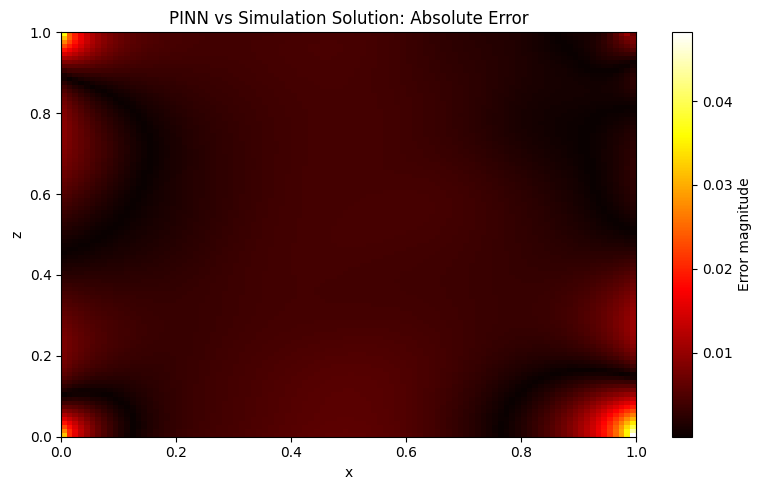

In [13]:
# Overview of the error between the PINN and simulation solutions

plt = plot_twoD_error('PINN vs Simulation Solution: Absolute Error', model2, res, x, z, ylabel='z')
plt.show()

# Complete Problem

In this concluding section of the series of notebooks, we will examine the complete form of the heat equation without any simplifications. Although, it is important to note that the homogeneous system will be maintained throughout the analysis.
The full heat equation is expressed as follows, with the chain rule for the outer derivation applied below:

$$
\begin {align*}
\dfrac{\partial u(x, z, t)}{\partial t} &= \nabla_{x,z} \Big[ \alpha(x, z) \cdot \nabla_{x,z} u(x, z, t) \Big] \\
&= \nabla_{x,z} \alpha(x, z) \cdot \nabla_{x,z} u(x, z, t) + \alpha(x, z) \cdot \Delta_{x,z} u(x, z, t)
\end{align*}
$$

The boundary conditions employed in this analysis are consistent with those utilized in the previous problems. The combination of these Neumann and Dirichlet boundary conditions, as observed in the first section, leads to singularities at the corners of the spatial domain, which introduce computational errors.
This phenomenon could be mitigated by selecting a more physically feasible set of boundary values. However, to achieve a more interesting result, we will keep the current values.

Dirichlet:
- $u(0,z,t) = 1$
- $u(1,z,t) = 0$

Neumann:
- $\dfrac{\partial u(x, z, t)}{\partial z} \Bigg|_{z = 0} = 0.5$
- $\dfrac{\partial u(x, z, t)}{\partial z} \Bigg|_{z = 1} = 0.5$

In contrast, the initial condition from previous analyses has been modified to eliminate the associated discontinuity and enhance the overall fitting of the results. The revised initial condition (visualized at the end of this notebook) is defined as follows:
- $u(x,z,0) = 1 - \sin(\frac{\pi}{2} \cdot x)$

As demonstrated above, we are also considering the material to exhibit variable diffusivity, which is modeled using the same "realistic" function employed in the previous section of the notebook titled `1D & time independent`. This function is extended in the z-direction, although it is important to note that z does not influence the shape of the flattened sigmoid function.

In this task, we are no longer relying on a simple manual implementation of the PINN. Instead, we are utilizing one of the most renowned packages available: [DeepXDE](https://arxiv.org/abs/1907.04502).

The primary reasons for this change are twofold: first, the implementations provided by these packages are **significantly more efficient**, likely resulting in improved performance of the PINNs and **employing more advanced training methodologies** (e.g. automated batching, automated data generation or even multi-task learning). Second, these packages offer **considerable versatility** in terms of the backend used (TensorFlow vs. PyTorch) and options for the PINNs themselves (e.g. various architectures), all with a relatively straightforward implementation.


Utilizing such a package simplifies the structure for creating a PINN, reducing the process to the following steps (listed in order of the code below):
- Definition of the _differential equation_
- Definition of the computational _problem space_
- Definition of the _boundary and initial conditions_
- Creation of the _model_

The first three components must be combined into a **data object**. This object automatically samples points for training and validation from the domain and computes the loss based on the model’s predictions and the corresponding input values.

It is important to note that the DeepXDE framework has some _complexities_ regarding compatibility with different backends. As of the current date (July 30, 2025), the combination with Keras 3 (included in newer versions of TensorFlow 2) is NOT compatible and will result in errors. Consequently, we are limited to using TensorFlow 1, which means that some features may be unavailable.

In [3]:
# Import the deepxde package
import deepxde as dde

# FYI: dde automatically searches for the most fitting backend that is available,
# but can also be manually set. However newer backends can be a bit complicated 
# to set up, as they require the installation of additional packages, often
# easily conflicting in the installed package versions.
# Here, for tensorflow, the most basic compatability is used, which should always
# work although it does not provide the most modern features. This version of the
# backend also breaks all other tensorflow 2 based functions in the notebooks.

# EXECUTING THE PREVIOUS CELLS AFTER THIS ONE WILL LEAD TO ERRORS!

Using backend: tensorflow.compat.v1
Other supported backends: tensorflow, pytorch, jax, paddle.
paddle supports more examples now and is recommended.


Instructions for updating:
non-resource variables are not supported in the long term


In [4]:
# Define the PDE and the domain of the problem

# Defin the 'real' distribution of diffusivity in the same way as in the
# last section of the `1D & time independent` notebook
def alph(x, k=7):
    # inverted sigmoid function, automatiaclly in [0, 1]
    # compatible with the auto-differentiation of tf
    sigmoid = 1 / (1 + tf.exp(k * (x[:, 0:1] - 0.5)))  # shape (N,1)
    return sigmoid

# Define the pde as a function of the input value x and
# the predicted value of the model y - both will be
# provided by the framework as np.arrays of all values
def heat_equation(x, y):
    a = alph(x)
    # first order derivatives
    a_x = dde.grad.jacobian(a, x, i=0, j=0)
    a_z = dde.grad.jacobian(a, x, i=0, j=1)
    y_x = dde.grad.jacobian(y, x, i=0, j=0)
    y_z = dde.grad.jacobian(y, x, i=0, j=1)
    y_t = dde.grad.jacobian(y, x, i=0, j=2)
    # second order derivatives
    y_xx = dde.grad.hessian(y, x, i=0, j=0)
    y_zz = dde.grad.hessian(y, x, i=0, j=1)
    # splitting in factors of the chain rule
    left = a_x * y_x + a_z * y_z
    right = a * (y_xx + y_zz)
    return y_t - (left + right)

# Define the dimensions of the time and spatial domain
spat_domain = dde.geometry.Rectangle([lower_bound, lower_bound], [upper_bound, upper_bound])  # [xmin, zmin], [xmax, zmax]
time_domain = dde.geometry.TimeDomain(lower_bound, upper_bound)
# Define the multi-dimensional space from which to draw the data
xzt_geometry = dde.geometry.GeometryXTime(spat_domain, time_domain)
# FYI: These geometry objects could also be changed to many other support forms.
# Eg: intervals, rectangles, polygons, or even custom constructed geometry

In [5]:
# Setup the boundary/initial conditions

# Set the Dirichlet boundary conditions in the x domain
x_bc = dde.icbc.DirichletBC(
    xzt_geometry,                 # specifies the computational domain on which the bc/s is/are defined
    lambda bps: 1 - bps[:, 0:1],  # takes a set of boundary (x,z,t)-points and computes the true y_bc
    lambda bp, on_boundary:       # the boundary indicator function defines which points count as boundary
        on_boundary and (
            dde.utils.isclose(bp[0], lower_bound) or dde.utils.isclose(bp[0], upper_bound)
        ) and (bp[-1] > lower_bound)  # do not apply for z domain or initial conditon
)
# FYI: The indicator function is boolean and takes 2 arguments:
#    1: a point from the computational domain
#    2: on_boundary flag, that is set true if the point from 1 is on
#       the boundary defined by the geometry.
# In simple xt-domains dde automatically knows to enforce the bcs only on the spatial domain.
# If, however, a multi-dimensional spatial domain is provided, the affected boundary must be
# explicitly specified.

# Set the Neumann boundary conditions in the z domain
# --> defined in the same way as the Dirichlet conditions
z_bc = dde.icbc.NeumannBC(
    xzt_geometry,
    lambda bps: 0.5,
    lambda bp, on_boundary:
        on_boundary and (
            # excluding the corner points where dirichlet conditions are active and inital conditon
            (dde.utils.isclose(bp[1], lower_bound) or dde.utils.isclose(bp[1], upper_bound)) and
            not (dde.utils.isclose(bp[0], lower_bound) or dde.utils.isclose(bp[0], upper_bound))
        ) and (bp[-1] > lower_bound)
)

# Set the initial conditon for the t-domain
ic = dde.icbc.IC(
    xzt_geometry,                                            # definition of the computational domain
    lambda bps: 1 - np.sin(0.5 * np.pi *  bps[:, 0:1]),      # function to compute the true intial solution
    lambda _, on_initial:                                    # condition function defining the initial time points
        on_initial
)
# FYI: The condition function is boolean and takes 2 arguments:
#    1: a point from the domain
#    2: on_initial flag, that is set to true if the point is given
#       on the lowest (first possible) coordinate of the t-domain.
# As before, for simple xzt-problems the initial condition is automatically applied to t.

In [6]:
# Set up the data model for the PINN by collecting the
# conditions, the space and the equation into 1 object
data = dde.data.TimePDE(
    xzt_geometry,       # set the computational domain from which to sample the points
    heat_equation,      # the pde to solve
    [x_bc, z_bc, ic],   # set of the boundary/initial conditions
    num_domain=3200,    # num of points to sample on the 'inside' of the geometry
    num_boundary=1500,  # num of points accross the boundary conditions
    num_initial=3200,   # num of points for the initial solution
    num_test=3200       # num of points to evaluate for validation
)
# FYI: TimePDE organizes all the information/sampling needed to solve a time-dependent
# PDE, respecting the different approaches in such a case.

First, here is some additional information regarding the implementations shown above:

It is _essential_ to understand the rationale behind applying the chain rule on the PDE in this context, as opposed to previous instances. The primary reason is that the DeepXDE framework doesn't like to compute the derivative of a derivative, a limitation not present in frameworks like TensorFlow. In DeepXDE, derivatives are determined by the elements indexed as $i,j$ within the corresponding Jacobian or Hessian matrices.
Furthermore, when defining the boundary and initial conditions, areas where conditions overlap are intentionally excluded. This exclusion is crucial to avoid over-defining points (creating singularities), which hinder the model’s ability to find a viable solution. While DeepXDE typically manages this process automatically, it is explicitly addressed here for clarity and illustrative purposes.

***

As previously mentioned, time-dependent PDEs represent a _significant challenge_ for PINNs. This challenge continues to be relevant here. Currently, there are **no** methods for causal training or domain decomposition impelmented in the framework, as discussed in the first problem of this notebook. However, the proposed combined approach of these two methods can be manually implemented in a relatively straightforward manner using a single PINN. To illustrate this application, the author hase included pseudocode for the changes that would need to be applied to the existing code:

<div style="font-size: 14px;margin-left: 1cm;">
<pre>

```python
# Decompose the spatial domain, here as an example into a 2x2 grid of sub-rectangles 
# but can be any integer > 2 or grid orientation
SET midPoint = 0.5  # adjust this to fit the chosen number of sub-rectangles
SET subdomains = EMPTY LIST
ADD Rectangle([0, 0], [midPoint, midPoint]) TO subdomains
ADD Rectangle([0, midPoint], [midPoint, 1]) TO subdomains
ADD Rectangle([midPoint, 0], [1, midPoint]) TO subdomains
ADD Rectangle([midPoint, midPoint], [1, 1]) TO subdomains
```
</pre>
<hr style="width: 25%; margin-left: 0px;">
<pre>

```python
# Define Boundary and conditions across all domains that touch the respective boundary
SET dirichlet = EMPTY LIST
ADD define_dirichlet_bc(rectangle_0, rectangle_1, ...) TO dirichlet # on x=0 edge
ADD define_dirichlet_bc(rectangle_2, rectangle_3, ...) TO dirichlet # on x=1 edge

SET neumann = EMPTY LIST
ADD define_neumann_bc(rectangle_0, rectangle_2, ...) TO neumann  # on z=0 edg
ADD define_neumann_bc(rectangle_1, rectangle_3, ...) TO neumann  # on z=1 edge
```
</pre>
<hr style="width: 25%; margin-left: 0px;">
<pre>

```python
# Decompose temporal domain, here as example in 3 steps
SET time_endpoints = [0.2, 0.5, 1.0]

# Introduce sequential learning AFTER compiling the model
FOR t_max IN time_endpoints
    # update temporal domain and define the whole problem domain
    SET time_domain = TimeDomain(0, t_max)
    SET geom_time = [GeometryXTime(sd, time_domain) FOR sd IN subdomains]

    # create the data object and update the model
    SET data = TimePDE(geom_time, [dirichlet, neumann, ...], ...)
    SET model.data = data

    # train the model
    DO model.train(...)
END FOR
```
</pre>
</div>

An alternative approach to existing methods is the **(Spatio-Temporal) Multi-scale Fourier Feature Network (STMsFFN)**. This PINN architecture is specifically designed to address the **spectral bias** associated with discontinuities in the problem definition (see last problem in the notebook `1D & time dependent`). The STMsFFN transforms input features (here spatial and temporal _separately_) into the frequency domain through _Fourier transforms_. Subsequently, it applies a _Gaussian windowing function_, characterized by its standard deviation (**sigma**), to the sum of all frequency components.
The multi-scale aspect of the STMsFFN facilitates the _simultaneous_ learning of multiple windowed frequency bands. This capability allows the network to effectively capture both the low-frequency components of the underlying regular function and the high-frequency components associated with discontinuities.

However, this approach is limited by the _increased requirement for more extensive training_ compared to traditional architectures. As can be seen below, in response to this, the number of epochs for training was significantly increased.
Additionally, the complexity of the architecture may introduce _challenges in hyperparameter_ tuning, making it more difficult to achieve convergence. For setting sigma without extensive tuning, one would typically start with a list like $[1, 10, 100]$ (reduced here to only the first two because of resource constraints) and adjust from there. No changes to the underlying neural network architecture are necessary, highlighting the great expressiveness of neural networks.

Further strategies to enhance performance include switching to **hard boundary conditions** and activating **adaptive resampling**. Hard boundary conditions impose stricter constraints on the solution at the domain’s edges compared to soft conditions. They are applied by enforcing their values _in the definition of the PDE_ rather than in the loss function, ensuring that the network always returns the specified value at the boundaries. Additionally, the adaptive resampling callback _dynamically adjusts the training data sampling_ based on the model’s performance, focusing on areas with higher error or uncertainty. This targeted approach improves both accuracy and convergence.

**ATTENTION: Exercise caution when running the cell below, as it utilizes the entire CPU and takes a significant amount of time to complete!**

Compiling model...
Building Spatio-temporal Multi-scale Fourier Feature Network...
'compile' took 3.527465 s

Training model...

Step      Train loss                                            Test loss                                             Test metric
0         [5.86e+03, 4.22e-01, 9.22e+00, 1.63e-01, 8.16e-02]    [5.93e+03, 4.22e-01, 9.22e+00, 1.63e-01, 8.16e-02]    []  
500       [1.07e+00, 1.15e-02, 1.78e-02, 8.70e-03, 8.05e-02]    [5.86e+00, 1.15e-02, 1.78e-02, 8.70e-03, 8.05e-02]    []  
1000      [3.28e-01, 5.75e-03, 6.84e-03, 3.87e-03, 8.04e-02]    [2.60e+00, 5.75e-03, 6.84e-03, 3.87e-03, 8.04e-02]    []  
1500      [1.55e-01, 1.83e-03, 3.81e-03, 1.85e-03, 8.03e-02]    [1.58e+00, 1.83e-03, 3.81e-03, 1.85e-03, 8.03e-02]    []  
2000      [8.77e-02, 7.30e-04, 2.47e-03, 1.09e-03, 7.98e-02]    [1.08e+00, 7.30e-04, 2.47e-03, 1.09e-03, 7.98e-02]    []  
2500      [5.48e-02, 4.54e-04, 1.74e-03, 8.25e-04, 7.90e-02]    [7.84e-01, 4.54e-04, 1.74e-03, 8.25e-04, 7.90e-02]    []  
300

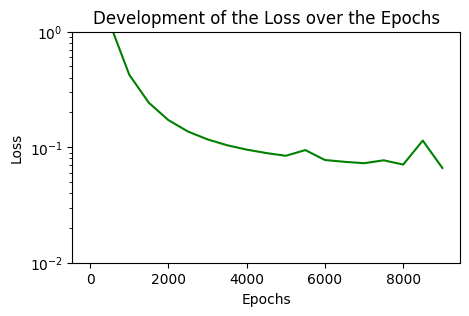

In [ ]:
# Train/Test a model for the full Problem

# Create and compile a model
net = dde.nn.STMsFFN([3] + [50]*5 + [1],      # [input dim] + layers * [#neurons per layer] + [output dim]
                "tanh",                       # activation function
                "Glorot uniform",             # initialization for the weights
                regularization=["l2", 1e-4],  # add L2 regularization
                sigmas_x=[1, 20],             # sigmas on x domain
                sigmas_t=[1, 20]              # sigmas on t domain
            )

model3 = dde.Model(data, net)           # create a model from the net and the data
model3.loss_weights = [1, 2, 2, 2, 1]   # weight the loss terms [inner, x_bc, z_bc, ic, reg]
model3.compile("adam", lr=1e-3)         # add optimizer and learning rate
# FYI: In the tensorflow.compat.v1 mode lr_schedules are not implemented.

# Set up checkpointing to save the model at its final epoch
checkpointer = dde.callbacks.ModelCheckpoint(
    "./data/full_2d/2D_model",  # overwriting the automatic file name
    verbose=0,                 # no output
    period=9000                # save every 9000 steps -> save only last one
)

# Train the model if it is not already trained
if os.path.exists('./data/full_2d/2D_model-9000.ckpt' + ".index"):
    # To force retraining of the model just change the string

    model3.restore('./data/full_2d/2D_model-9000.ckpt')
else:
    losshistory, train_state = model3.train(
        iterations=9000,          # iterations = max number of epochs
        display_every=500,        # how often the function prints the loss
        callbacks=[checkpointer]  # assing the callback for saving the model
    )

    # Create a graph showing the loss vs the epochs
    x = np.array(losshistory.steps)
    y = np.array([np.sum(loss) for loss in losshistory.loss_train])
    data = list([x, y, 'g-', 'Model Loss'])
    plt = plot_err_vs_epoch(data, 'Development of the Loss over the Epochs', xlabel='Epochs', ylabel='Loss')
    plt.show()

# Create a test data set for the visual comparison
xz_test = xzt_geometry.geometry.uniform_points(10000, True)
# Add discretized t dimension and calculate the predictions
time_steps = np.array([i/10 for i in range(10+1)])
all_pred = []
for t in time_steps:
    # create a column of the time step and concat with space
    t_column = t * np.ones((10000, 1))
    points_at_t = np.hstack([xz_test, t_column])
    # predict and reshape the values
    y_pred = model3.predict(points_at_t).reshape(100, 100).T
    all_pred.append(y_pred)

# Plot the solution for a selection of time steps
x_samps = np.linspace(lower_bound, upper_bound, 100)
z_samps = np.linspace(lower_bound, upper_bound, 100)
X, Z = np.meshgrid(x_samps, z_samps)

plt = mult_3D_plot(X, Z, all_pred, time_steps, 'Plot of the PINN solution at different time steps', ylabel='z', zlabel=r'u(x, z, $t_{step}$)')
plt.show()

First, it is important to note that the loss printed by the training function above appears _larger than it actually is_. This is because it sums up all terms, with the last term being the regularization term, which should not be minimized too aggressively.

Next, a comparison can be made between the initial solution and the plotted version below. It is immediately evident that the **general form matches** in both versions. However, in the predicted version from the PINN, the corners are pointed upwards, and the Dirichlet conditions are not _fully_ satisfied. As previously mentioned, this phenomenon arises from the _non-causal nature_ of the learning process and is an artifact of the boundary conditions from later time steps.

As we progress along the time axis, a significant change is observed initially, followed by a slowdown towards the end. Throughout this process, a **distinct wavy form** is evident on the surface, which is a direct consequence of the non-zero Neumann conditions. These conditions also contribute to the peaks observed in the corners. Despite these issues, the Dirichlet conditions seem _relatively_ **well satisfied**. This can be attributed to the STMsFFN model itself, which helps to compensate for the discontinuities in areas where the Dirichlet and Neumann conditions conflict. 

At the end of the time domain, the solution converges towards a form that **closely resembles** the realistic version presented in the material variations section again of the notebook titled `1D & time independent`. This alignment is logical, as the same material distribution was used here, and a very similar version (albeit not entirely the same) of the steady-state solution for the general heat equation was calculated in both cases.

In [9]:
# Visualize the initial solution
xz_test = xzt_geometry.geometry.uniform_points(1024, True)

# Add t dimension for inital solution at t=0
t_column = 0 * np.ones((1024, 1))
points_at_t = np.hstack([xz_test, t_column])
# calculate and reshape the values
y_init = 1 - np.sin(0.5 * np.pi *  points_at_t[:, 0:1]).reshape(32,32).T

# Plot the solution for a selection of time steps
x_samps = np.linspace(lower_bound, upper_bound, 32)
z_samps = np.linspace(lower_bound, upper_bound, 32)
X, Z = np.meshgrid(x_samps, z_samps)

plt = int_3D_plot(X, Z, y_init, 'Plot of the PINN solution at different time steps', ylabel='z', zlabel='u(x, z, 0)')
plt.show()